In [1]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import anndata
import seaborn as sns
import matplotlib.pyplot as plt
sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor='white') 
from scipy.stats.mstats import winsorize
import anndata as ad
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("measurements.csv")
data

,80ArAr,89Y_Vimentin,113In_Ecad,115In_PanCK,126Xe,131Xe,134Xe,139La_KLC,141Pr_HLA-DR,142Nd_CD303,...,image_acquisition_description,image_acquisition_start_x_um,image_acquisition_start_y_um,image_acquisition_end_x_um,image_acquisition_end_y_um,image_acquisition_width_um,image_acquisition_height_um,phenograph,phenotypeSearch,leiden
0,1179.196411,22.250000,0.107143,0.500000,0.000000,5.767857,2.258929,0.892857,0.035714,2.071429,...,H110009826_D23_L.C_T00030,40182.979,14498.095,40815.979,13653.095,633,845,1,Unassigned,4
1,1186.547852,18.805851,0.021277,0.117021,0.053191,5.199468,2.569149,0.978723,0.106383,1.090425,...,H110009826_D23_L.C_T00030,40182.979,14498.095,40815.979,13653.095,633,845,19,Unassigned,17
2,1177.336914,2.810869,0.008696,0.347826,0.026087,5.343478,2.473913,0.391304,0.043478,0.060870,...,H110009826_D23_L.C_T00030,40182.979,14498.095,40815.979,13653.095,633,845,21,Unassigned,20
3,1202.292725,5.469512,0.097561,0.097561,0.048780,5.646341,2.591463,0.554878,0.048780,0.317073,...,H110009826_D23_L.C_T00030,40182.979,14498.095,40815.979,13653.095,633,845,13,Unassigned,0
4,1169.788452,4.759615,0.115385,0.076923,0.000000,5.240385,2.269231,0.192308,0.000000,0.230769,...,H110009826_D23_L.C_T00030,40182.979,14498.095,40815.979,13653.095,633,845,13,Unassigned,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286452,1125.622559,0.882353,0.098039,0.058824,0.039216,6.779412,3.617647,0.588235,0.848039,0.264706,...,H120002256_C31_L.S_T00116,11202.855,15897.563,12578.855,14716.563,1376,1181,27,Unassigned,6
286453,1109.588257,4.286765,0.029412,0.117647,0.029412,6.492647,3.639706,0.647059,0.794118,0.647059,...,H120002256_C31_L.S_T00116,11202.855,15897.563,12578.855,14716.563,1376,1181,28,Unassigned,6
286454,1084.947632,22.174419,0.139535,0.279070,0.023256,5.965117,3.598837,0.767442,0.465116,0.627907,...,H120002256_C31_L.S_T00116,11202.855,15897.563,12578.855,14716.563,1376,1181,16,Unassigned,29
286455,1081.304321,21.847826,0.043478,0.173913,0.043478,5.913043,3.652174,1.021739,0.347826,0.217391,...,H120002256_C31_L.S_T00116,11202.855,15897.563,12578.855,14716.563,1376,1181,16,Unassigned,29


In [3]:
columns_to_drop = ['80ArAr', '126Xe', '131Xe', '134Xe','206Pb','208Pb', '191Ir_DNA1', '193Ir_DNA2', 'leiden']
data = data.drop(columns=columns_to_drop)

In [4]:
def normalize_data(df):
    metadata = df[['description', 'cell_id', 'sample', 'Image', 'area',
       'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length',
       'eccentricity', 'image', 'image_width_px', 'image_height_px',
       'image_num_channels', 'image_source_file', 'image_recovery_file',
       'image_recovered', 'image_acquisition_id',
       'image_acquisition_description', 'image_acquisition_start_x_um',
       'image_acquisition_start_y_um', 'image_acquisition_end_x_um',
       'image_acquisition_end_y_um', 'image_acquisition_width_um',
       'image_acquisition_height_um', 'phenograph', 'phenotypeSearch']]
    df = df.drop(columns=['description', 'cell_id', 'sample', 'Image', 'area',
       'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length',
       'eccentricity', 'image', 'image_width_px', 'image_height_px',
       'image_num_channels', 'image_source_file', 'image_recovery_file',
       'image_recovered', 'image_acquisition_id',
       'image_acquisition_description', 'image_acquisition_start_x_um',
       'image_acquisition_start_y_um', 'image_acquisition_end_x_um',
       'image_acquisition_end_y_um', 'image_acquisition_width_um',
       'image_acquisition_height_um', 'phenograph', 'phenotypeSearch'])
    cutoff_value = np.percentile(df.values, q=99.9, axis=0)
    df = df[(df.values < cutoff_value).all(axis=1)]
    max_value = np.max(df.values, axis=0)
    df = df / max_value
    df[['description', 'cell_id', 'sample', 'Image', 'area',
       'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length',
       'eccentricity', 'image', 'image_width_px', 'image_height_px',
       'image_num_channels', 'image_source_file', 'image_recovery_file',
       'image_recovered', 'image_acquisition_id',
       'image_acquisition_description', 'image_acquisition_start_x_um',
       'image_acquisition_start_y_um', 'image_acquisition_end_x_um',
       'image_acquisition_end_y_um', 'image_acquisition_width_um',
       'image_acquisition_height_um', 'phenograph', 'phenotypeSearch']] = metadata.loc[df.index]
    return df

In [5]:
data_normalized = normalize_data(data)

In [6]:
data_normalized = data_normalized.reset_index(drop=True)

In [7]:
metadata_columns = ['description', 'cell_id', 'sample', 'Image', 'area',
       'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length',
       'eccentricity', 'image', 'image_width_px', 'image_height_px',
       'image_num_channels', 'image_source_file', 'image_recovery_file',
       'image_recovered', 'image_acquisition_id',
       'image_acquisition_description', 'image_acquisition_start_x_um',
       'image_acquisition_start_y_um', 'image_acquisition_end_x_um',
       'image_acquisition_end_y_um', 'image_acquisition_width_um',
       'image_acquisition_height_um', 'phenograph', 'phenotypeSearch']
# Separate the metadata from the main data
metadata = data_normalized[metadata_columns]
main_data = data_normalized.drop(columns=metadata_columns)

# Create the AnnData object with the numerical main data
data_ad = sc.AnnData(X=main_data)

# Add the metadata to the AnnData object
data_ad.obs = metadata

/home/admin/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


/home/admin/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/admin/.local/lib/python3.10/site-packages/umap/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/tmp/ipykernel_65026/4085607762.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(data_ad, resolution = 1)
/home/admin/.local/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: SettingWith

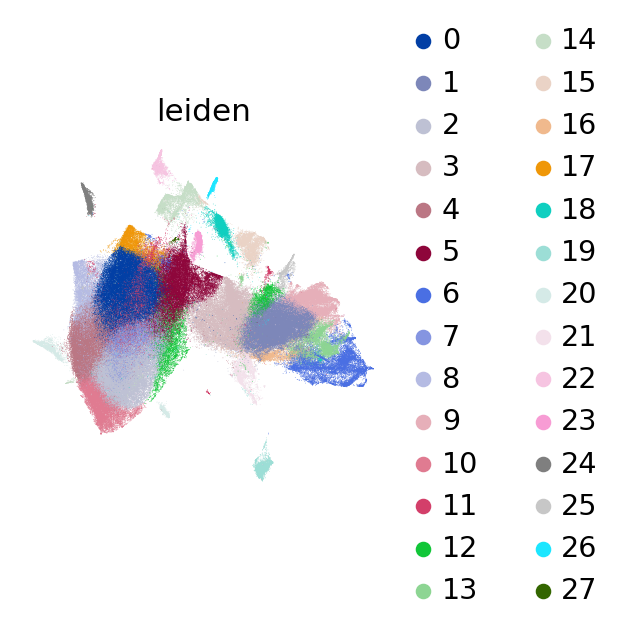

In [8]:
sc.pp.neighbors(data_ad)
sc.tl.umap(data_ad, min_dist=0.1, n_components=2)
sc.tl.leiden(data_ad, resolution = 1)
sc.pl.umap(data_ad, color='leiden')

In [9]:
data_ad.write("./rakaia_dataset_clustered.h5ad")